In [1]:
import kagglehub

path = kagglehub.dataset_download("carrie1/ecommerce-data")

print("Path to dataset files:", path)

100%|██████████| 7.20M/7.20M [00:00<00:00, 18.8MB/s]

Extracting files...


Path to dataset files: /home/d12753be-8f30-4c2a-b991-36a83041f79f/.cache/kagglehub/datasets/carrie1/ecommerce-data/versions/1


In [2]:
import os

print("Files in dataset:")
for file in os.listdir(path):
    print(file)

Files in dataset:
data.csv


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv(path + "/data.csv", encoding='unicode_escape')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Check data quality
print("Missing values:")
print(df.isnull().sum())

print("\nDate range:")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

print("\nUnique customers:", df['CustomerID'].nunique())
print("Unique countries:", df['Country'].nunique())

print("\nNegative quantities (returns):", (df['Quantity'] < 0).sum())
print("Negative prices:", (df['UnitPrice'] <= 0).sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Unique customers: 4372
Unique countries: 38

Negative quantities (returns): 10624
Negative prices: 2517


In [5]:
# Clean the data
df_clean = df.copy()

# Drop missing CustomerIDs - can't track behavior without them
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove returns and zero/negative prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Create revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Check what we have left
print("Clean dataset shape:", df_clean.shape)
print("Unique customers remaining:", df_clean['CustomerID'].nunique())
print("Total revenue in dataset: £{:,.2f}".format(df_clean['Revenue'].sum()))
print("\nSample of clean data:")
df_clean.head()

Clean dataset shape: (397884, 9)
Unique customers remaining: 4338
Total revenue in dataset: £8,911,407.90

Sample of clean data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:
import numpy as np

# Set reference date as day after last transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Roll up to customer level
customer_df = df_clean.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    total_orders=('InvoiceNo', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean')
).reset_index()

# Calculate days since last purchase
customer_df['days_since_purchase'] = (reference_date - customer_df['last_purchase']).dt.days

# Calculate customer lifespan in days
customer_df['customer_lifespan_days'] = (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days

# Round revenue columns
customer_df['total_revenue'] = customer_df['total_revenue'].round(2)
customer_df['avg_order_value'] = customer_df['avg_order_value'].round(2)

print("Customer level dataset shape:", customer_df.shape)
print("\nSample:")
customer_df.head()

Customer level dataset shape: (4338, 8)

Sample:


,CustomerID,first_purchase,last_purchase,total_orders,total_revenue,avg_order_value,days_since_purchase,customer_lifespan_days
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.60,326,0
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,23.68,2,365
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,57.98,75,282
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,24.08,19,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.67,310,0


In [7]:
# Create lapse segments
def lapse_segment(days):
    if days <= 90:
        return '0-90 days (active)'
    elif days <= 180:
        return '91-180 days (warm)'
    elif days <= 365:
        return '181-365 days (lapsed)'
    else:
        return '365+ days (deep lapsed)'

customer_df['lapse_segment'] = customer_df['days_since_purchase'].apply(lapse_segment)

# Add acquisition cost estimate (industry standard ~£10 per customer)
customer_df['acquisition_cost'] = 10

# Add reactivation cost by segment (cost increases with lapse length)
reactivation_costs = {
    '0-90 days (active)': 2,
    '91-180 days (warm)': 5,
    '181-365 days (lapsed)': 8,
    '365+ days (deep lapsed)': 12
}
customer_df['reactivation_cost'] = customer_df['lapse_segment'].map(reactivation_costs)

# Segment summary
segment_summary = customer_df.groupby('lapse_segment').agg(
    customers=('CustomerID', 'count'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    reactivation_cost=('reactivation_cost', 'first')
).reset_index()

segment_summary['avg_order_value'] = segment_summary['avg_order_value'].round(2)
segment_summary['avg_revenue'] = segment_summary['avg_revenue'].round(2)

print(segment_summary)

             lapse_segment  customers  avg_order_value  avg_revenue  \
0       0-90 days (active)       2889            50.77      2726.25   
1    181-365 days (lapsed)        791           157.23       672.25   
2  365+ days (deep lapsed)         69            49.55       352.76   
3       91-180 days (warm)        589            37.41       813.55   

   reactivation_cost  
0                  2  
1                  8  
2                 12  
3                  5  


In [8]:
# Calculate expected return on reactivation by segment
# Industry win-back response rates by lapse length
response_rates = {
    '0-90 days (active)': 0.45,
    '91-180 days (warm)': 0.25,
    '181-365 days (lapsed)': 0.15,
    '365+ days (deep lapsed)': 0.05
}

segment_summary['response_rate'] = segment_summary['lapse_segment'].map(response_rates)

# Expected revenue per customer contacted
segment_summary['expected_revenue'] = (
    segment_summary['avg_order_value'] * segment_summary['response_rate']
).round(2)

# Net return (expected revenue minus reactivation cost)
segment_summary['net_return'] = (
    segment_summary['expected_revenue'] - segment_summary['reactivation_cost']
).round(2)

# ROI on reactivation
segment_summary['reactivation_roi'] = (
    (segment_summary['net_return'] / segment_summary['reactivation_cost']) * 100
).round(1)

# Is reactivation worth it vs acquisition?
segment_summary['worth_reactivating'] = segment_summary['net_return'] > 0

print("Win-Back Break Even Analysis:")
print(segment_summary[['lapse_segment', 'response_rate', 'expected_revenue', 
                         'reactivation_cost', 'net_return', 'reactivation_roi', 
                         'worth_reactivating']])

Win-Back Break Even Analysis:
             lapse_segment  response_rate  expected_revenue  \
0       0-90 days (active)           0.45             22.85   
1    181-365 days (lapsed)           0.15             23.58   
2  365+ days (deep lapsed)           0.05              2.48   
3       91-180 days (warm)           0.25              9.35   

   reactivation_cost  net_return  reactivation_roi  worth_reactivating  
0                  2       20.85            1042.5                True  
1                  8       15.58             194.8                True  
2                 12       -9.52             -79.3               False  
3                  5        4.35              87.0                True  


In [9]:
#Reactivation is worth pursuing for customers lapsed up to 12 months — but deep lapsed customers beyond 365 days cost more to win back than they return. Budget is better spent on acquisition or retention of active customers.

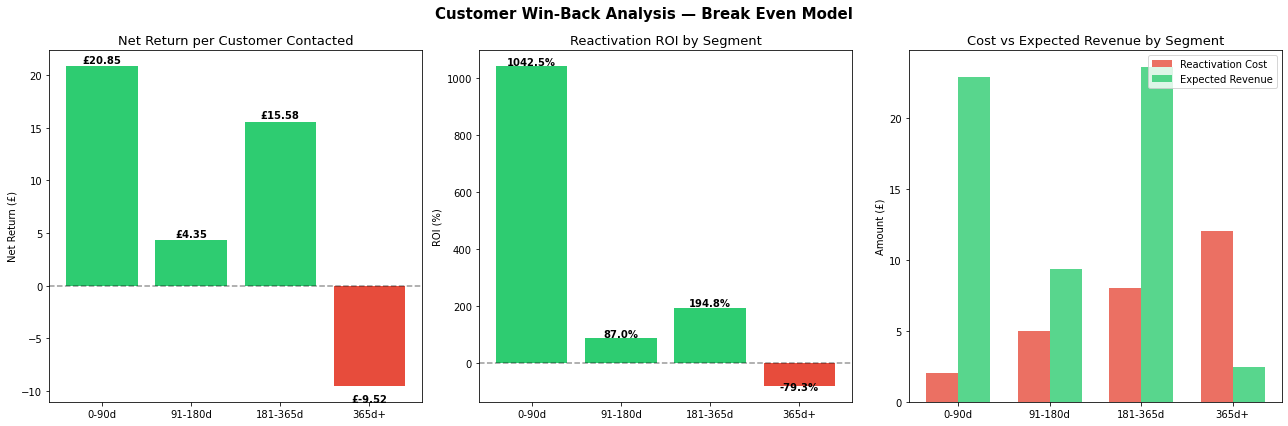

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sort by lapse order
order = ['0-90 days (active)', '91-180 days (warm)', 
         '181-365 days (lapsed)', '365+ days (deep lapsed)']
segment_summary = segment_summary.set_index('lapse_segment').reindex(order).reset_index()

# Chart 1 - Net return by segment
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in segment_summary['net_return']]
bars = axes[0].bar(range(len(segment_summary)), segment_summary['net_return'], color=colors)
axes[0].set_title('Net Return per Customer Contacted', fontsize=13)
axes[0].set_ylabel('Net Return (£)')
axes[0].set_xticks(range(len(segment_summary)))
axes[0].set_xticklabels(['0-90d', '91-180d', '181-365d', '365d+'], fontsize=10)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.4)
for bar, val in zip(bars, segment_summary['net_return']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.3 if val > 0 else bar.get_height() - 1.5,
                f'£{val}', ha='center', fontsize=10, fontweight='bold')

# Chart 2 - Reactivation ROI
colors2 = ['#2ecc71' if x > 0 else '#e74c3c' for x in segment_summary['reactivation_roi']]
bars2 = axes[1].bar(range(len(segment_summary)), segment_summary['reactivation_roi'], color=colors2)
axes[1].set_title('Reactivation ROI by Segment', fontsize=13)
axes[1].set_ylabel('ROI (%)')
axes[1].set_xticks(range(len(segment_summary)))
axes[1].set_xticklabels(['0-90d', '91-180d', '181-365d', '365d+'], fontsize=10)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, segment_summary['reactivation_roi']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5 if val > 0 else bar.get_height() - 15,
                f'{val}%', ha='center', fontsize=10, fontweight='bold')

# Chart 3 - Cost vs Expected Revenue
x = np.arange(len(segment_summary))
width = 0.35
axes[2].bar(x - width/2, segment_summary['reactivation_cost'], width, 
            label='Reactivation Cost', color='#e74c3c', alpha=0.8)
axes[2].bar(x + width/2, segment_summary['expected_revenue'], width,
            label='Expected Revenue', color='#2ecc71', alpha=0.8)
axes[2].set_title('Cost vs Expected Revenue by Segment', fontsize=13)
axes[2].set_ylabel('Amount (£)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['0-90d', '91-180d', '181-365d', '365d+'], fontsize=10)
axes[2].legend()

plt.suptitle('Customer Win-Back Analysis — Break Even Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
#Win-back investment pays off for customers lapsed up to 12 months — but beyond 365 days the cost of reactivation exceeds expected return. Organizations should intervene early or not at all.

In [12]:
# Budget allocation recommendation
total_winback_budget = 10000  # £10,000 example budget

# Allocate by ROI weight (only positive ROI segments)
positive_segments = segment_summary[segment_summary['net_return'] > 0].copy()
positive_segments['roi_weight'] = (
    positive_segments['reactivation_roi'] / positive_segments['reactivation_roi'].sum()
)
positive_segments['recommended_budget'] = (
    positive_segments['roi_weight'] * total_winback_budget
).round(0)
positive_segments['customers_reachable'] = (
    positive_segments['recommended_budget'] / positive_segments['reactivation_cost']
).round(0)
positive_segments['expected_total_revenue'] = (
    positive_segments['customers_reachable'] * positive_segments['expected_revenue']
).round(0)

print("Win-Back Budget Recommendation (£10,000 total):")
print(positive_segments[['lapse_segment', 'recommended_budget', 
                           'customers_reachable', 'expected_total_revenue',
                           'reactivation_roi']])

print("\nTotal expected revenue from win-back campaign: £{:,.0f}".format(
    positive_segments['expected_total_revenue'].sum()))
print("Total investment: £{:,.0f}".format(total_winback_budget))
print("Overall campaign ROI: {:.0f}%".format(
    (positive_segments['expected_total_revenue'].sum() - total_winback_budget) / 
    total_winback_budget * 100))

Win-Back Budget Recommendation (£10,000 total):
           lapse_segment  recommended_budget  customers_reachable  \
0     0-90 days (active)              7872.0               3936.0   
1     91-180 days (warm)               657.0                131.0   
2  181-365 days (lapsed)              1471.0                184.0   

   expected_total_revenue  reactivation_roi  
0                 89938.0            1042.5  
1                  1225.0              87.0  
2                  4339.0             194.8  

Total expected revenue from win-back campaign: £95,502
Total investment: £10,000
Overall campaign ROI: 855%


In [13]:
#A £10,000 win-back campaign targeting customers lapsed under 12 months generates an estimated £95,502 in revenue — an 855% ROI. Deep lapsed customers beyond 365 days receive zero budget as reactivation cost exceeds expected return